<a href="https://colab.research.google.com/github/emanuelmejia/4GeeksAcademy/blob/master/L04-Transform_Suavizamiento/notebooks/L04_3_HoltWinters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# **Holt Winters**

In [2]:
# Subir archivo aus_wine.dat
from google.colab import files
files.upload()

Saving aus_wine.dat to aus_wine (4).dat


{'aus_wine (4).dat': b'winet\tfortw\tdryw\tsweetw\tred\trose\tspark\n1\t2585\t1954\t85\t464\t112\t1686\n2\t3368\t2302\t89\t675\t118\t1591\n3\t3210\t3054\t109\t703\t129\t2304\n4\t3111\t2414\t95\t887\t99\t1712\n5\t3756\t2226\t91\t1139\t116\t1471\n6\t4216\t2725\t95\t1077\t168\t1377\n7\t5225\t2589\t96\t1318\t118\t1966\n8\t4426\t3470\t128\t1260\t129\t2453\n9\t3932\t2400\t124\t1120\t205\t1984\n10\t3816\t3180\t111\t963\t147\t2596\n11\t3661\t4009\t178\t996\t150\t4087\n12\t3795\t3924\t140\t960\t267\t5179\n13\t2285\t2072\t150\t530\t126\t1530\n14\t2934\t2434\t132\t883\t129\t1523\n15\t2985\t2956\t155\t894\t124\t1633\n16\t3646\t2828\t132\t1045\t97\t1976\n17\t4198\t2687\t91\t1199\t102\t1170\n18\t4935\t2629\t94\t1287\t127\t1480\n19\t5618\t3150\t109\t1565\t222\t1781\n20\t5454\t4119\t155\t1577\t214\t2472\n21\t3624\t3030\t123\t1076\t118\t1981\n22\t2898\t3055\t130\t918\t141\t2273\n23\t3802\t3821\t150\t1008\t154\t3857\n24\t2369\t4001\t163\t1063\t226\t4551\n25\t2369\t2529\t101\t544\t89\t1510\n26\t2511\t247

In [3]:
# Leer el archivo aus_wine.dat
df_full = pd.read_csv('/content/aus_wine.dat', sep='\t')
df_full.head()

,winet,fortw,dryw,sweetw,red,rose,spark
0,1,2585,1954,85,464,112,1686
1,2,3368,2302,89,675,118,1591
2,3,3210,3054,109,703,129,2304
3,4,3111,2414,95,887,99,1712
4,5,3756,2226,91,1139,116,1471


In [4]:
df_full['Fecha'] = pd.period_range(start='1980-01', periods=len(df_full), freq='M')
df_full = df_full.set_index('Fecha')
df_full.index = df_full.index.to_timestamp()
df_full.head()

,winet,fortw,dryw,sweetw,red,rose,spark
Fecha,,,,,,,
1980-01-01,1,2585,1954,85,464,112,1686
1980-02-01,2,3368,2302,89,675,118,1591
1980-03-01,3,3210,3054,109,703,129,2304
1980-04-01,4,3111,2414,95,887,99,1712
1980-05-01,5,3756,2226,91,1139,116,1471


In [5]:
df = df_full['sweetw'].to_frame()
df = df.dropna()
df.head()

,sweetw
Fecha,
1980-01-01,85
1980-02-01,89
1980-03-01,109
1980-04-01,95
1980-05-01,91


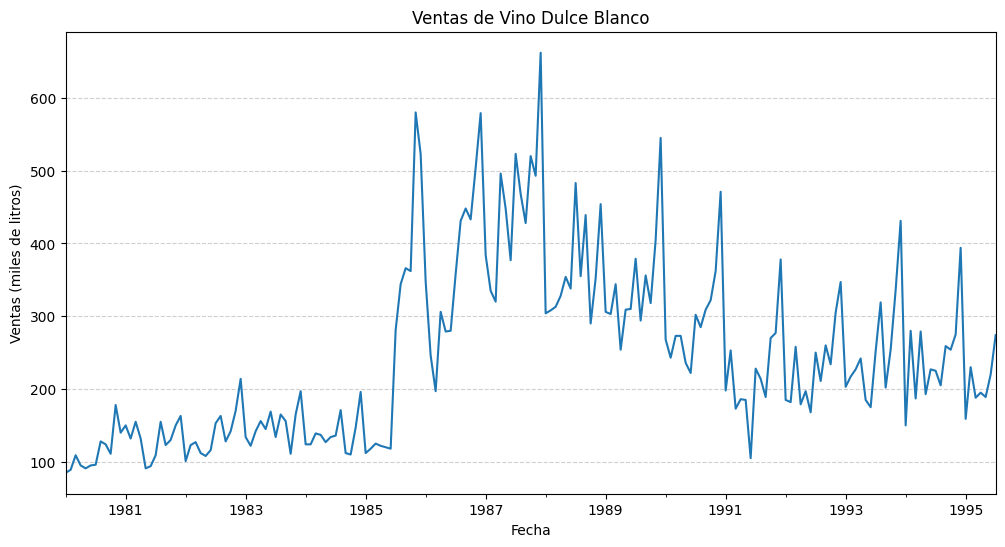

In [6]:
columna = 'sweetw'

# Gráfico inicial
plt.figure(figsize=(12, 6))
df[columna].plot()

# Etiquetas
plt.title('Ventas de Vino Dulce Blanco')
plt.xlabel('Fecha')
plt.ylabel('Ventas (miles de litros)')

#Formato final
plt.grid(False, axis = 'x')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [7]:
# Aplicar Holt-Winters con alpha = 0.2, beta = 0.2, gamma = 0.2
hw_manual = ExponentialSmoothing(df['sweetw'],
                              seasonal_periods=12,
                              trend='add', # Suponiendo tendencia aditiva
                              seasonal='add' # Suponiendo estacionalidad aditiva
                            ).fit(
                            smoothing_level=0.2,
                            smoothing_trend=0.2,
                            smoothing_seasonal=0.2
                            )
df['hw_manual'] = hw_manual.fittedvalues
df.head()

,sweetw,hw_manual
Fecha,,
1980-01-01,85,79.857902
1980-02-01,89,79.679219
1980-03-01,109,96.820853
1980-04-01,95,107.184991
1980-05-01,91,93.653543


In [8]:
# Aplicar Holt-Winters dejando que los parámetros se calculen automáticamente
hw_auto = ExponentialSmoothing(df['sweetw'],
                              seasonal_periods=12,
                              trend='add', # Suponiendo tendencia aditiva
                              seasonal='add', # Suponiendo estacionalidad aditiva
                            ).fit()

df['hw_auto'] = hw_auto.fittedvalues
df.head()

,sweetw,hw_manual,hw_auto
Fecha,,,
1980-01-01,85,79.857902,88.561989
1980-02-01,89,79.679219,92.736030
1980-03-01,109,96.820853,89.141826
1980-04-01,95,107.184991,112.273930
1980-05-01,91,93.653543,89.195400


In [9]:
# Guardar y mostrar los valores de alpha, beta y gamma calculados automáticamente
print(f"Alpha: {hw_auto.params['smoothing_level']:.4f}")
print(f"Beta: {hw_auto.params['smoothing_trend']:.4f}")
print(f"Gamma: {hw_auto.params['smoothing_seasonal']:.4f}")

Alpha: 0.4856
Beta: 0.0000
Gamma: 0.0000


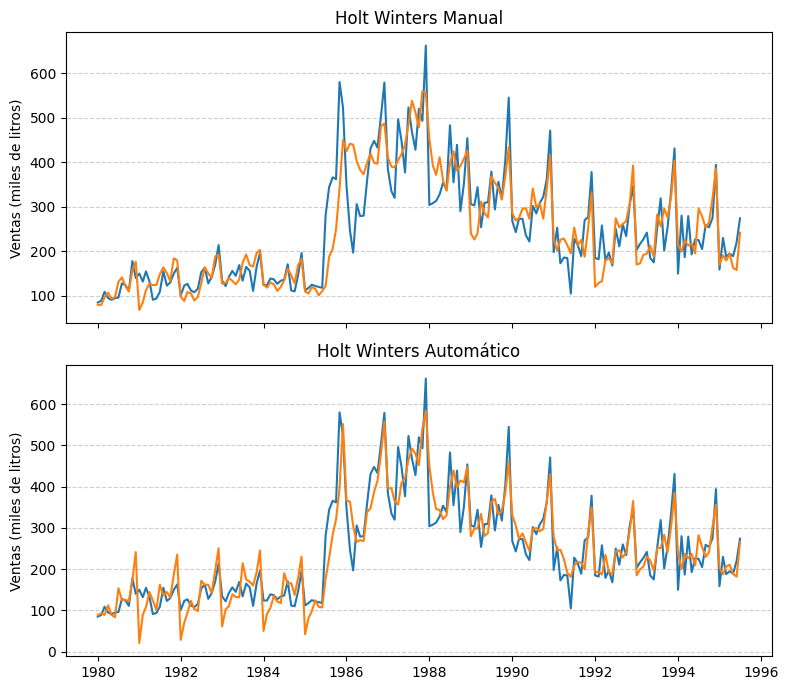

In [10]:
fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Gráfico superior: Mucho Suavizamiento
ax[0].plot(df.index, df['sweetw'], label='Original')
ax[0].plot(df.index, df['hw_manual'], label='Holt Winters Manual')
ax[0].set_title('Holt Winters Manual')
ax[0].set_ylabel('Ventas (miles de litros)')
ax[0].grid(axis='y', linestyle='--', alpha=0.6)

# Gráfico inferior: Poco Suavizamiento
ax[1].plot(df.index, df['sweetw'], label='Original')
ax[1].plot(df.index, df['hw_auto'], label='Holt Winters Automático')
ax[1].set_title('Holt Winters Automático')
ax[1].set_ylabel('Ventas (miles de litros)')
ax[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# **Datos de Pasajeros**

In [11]:
from google.colab import files
files.upload()

Saving pas.csv to pas (3).csv


{'pas (3).csv': b'Periodo,Pasajeros\r\n1,112\r\n2,118\r\n3,132\r\n4,129\r\n5,121\r\n6,135\r\n7,148\r\n8,148\r\n9,136\r\n10,119\r\n11,104\r\n12,118\r\n13,115\r\n14,126\r\n15,141\r\n16,135\r\n17,125\r\n18,149\r\n19,170\r\n20,170\r\n21,158\r\n22,133\r\n23,114\r\n24,140\r\n25,145\r\n26,150\r\n27,178\r\n28,163\r\n29,172\r\n30,178\r\n31,199\r\n32,199\r\n33,184\r\n34,162\r\n35,146\r\n36,166\r\n37,171\r\n38,180\r\n39,193\r\n40,181\r\n41,183\r\n42,218\r\n43,230\r\n44,242\r\n45,209\r\n46,191\r\n47,172\r\n48,194\r\n49,196\r\n50,196\r\n51,236\r\n52,235\r\n53,229\r\n54,243\r\n55,264\r\n56,272\r\n57,237\r\n58,211\r\n59,180\r\n60,201\r\n61,204\r\n62,188\r\n63,235\r\n64,227\r\n65,234\r\n66,264\r\n67,302\r\n68,293\r\n69,259\r\n70,229\r\n71,203\r\n72,229\r\n73,242\r\n74,233\r\n75,267\r\n76,269\r\n77,270\r\n78,315\r\n79,364\r\n80,347\r\n81,312\r\n82,274\r\n83,237\r\n84,278\r\n85,284\r\n86,277\r\n87,317\r\n88,313\r\n89,318\r\n90,374\r\n91,413\r\n92,405\r\n93,355\r\n94,306\r\n95,271\r\n96,306\r\n97,315\r\n

In [12]:
df = pd.read_csv("/content/pas.csv")
df['Fecha'] = pd.period_range(start='1949-01', periods=len(df), freq='M')
df = df.set_index('Fecha')
df = df.drop(columns=['Periodo'])
# Convertir a índice Datetime para compatibilidad con descomposición
df.index = df.index.to_timestamp()
df.head()

,Pasajeros
Fecha,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


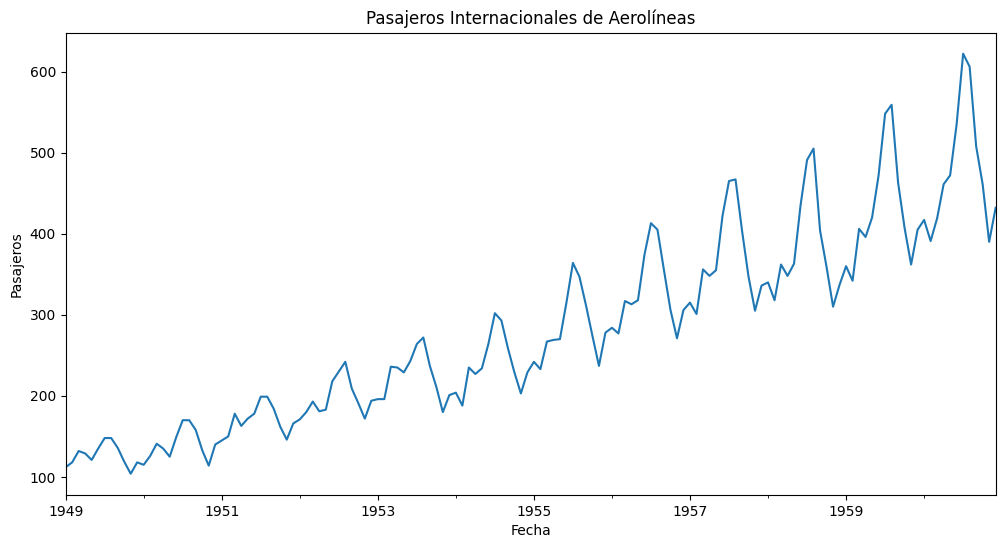

In [13]:
plt.figure(figsize=(12, 6))
df['Pasajeros'].plot()
plt.title('Pasajeros Internacionales de Aerolíneas')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.show()

In [14]:
# Aplicar Holt-Winters dejando que los parámetros se calculen automáticamente para 'Pasajeros'
hwPasManual = ExponentialSmoothing(df['Pasajeros'],
                                       seasonal_periods=12,
                                       trend='add', # Suponiendo tendencia aditiva
                                       seasonal='add', # Suponiendo estacionalidad multiplicativa
                                      ).fit(
                                        smoothing_level=0.2,
                                        smoothing_trend=0.2,
                                        smoothing_seasonal=0.2
                                      )

df['hwPasManual'] = hwPasManual.fittedvalues

In [15]:
# Guardar y mostrar los valores de alpha, beta y gamma calculados automáticamente
print(f"Alpha: {hwPasManual.params['smoothing_level']:.4f}")
print(f"Beta: {hwPasManual.params['smoothing_trend']:.4f}")
print(f"Gamma: {hwPasManual.params['smoothing_seasonal']:.4f}")

Alpha: 0.2000
Beta: 0.2000
Gamma: 0.2000


In [16]:
# Aplicar Holt-Winters dejando que los parámetros se calculen automáticamente para 'Pasajeros'
hwPasAutoA = ExponentialSmoothing(df['Pasajeros'],
                                       seasonal_periods=12,
                                       trend='add', # Suponiendo tendencia aditiva
                                       seasonal='add', # Suponiendo estacionalidad aditiva
                                      ).fit()

df['hwPasAutoA'] = hwPasAutoA.fittedvalues

In [17]:
# Guardar y mostrar los valores de alpha, beta y gamma calculados automáticamente
print(f"Alpha: {hwPasAutoA.params['smoothing_level']:.4f}")
print(f"Beta: {hwPasAutoA.params['smoothing_trend']:.4f}")
print(f"Gamma: {hwPasAutoA.params['smoothing_seasonal']:.4f}")

Alpha: 0.2525
Beta: 0.0000
Gamma: 0.7475


In [18]:
# Aplicar Holt-Winters dejando que los parámetros se calculen automáticamente para 'Pasajeros'
hwPasAutoM = ExponentialSmoothing(df['Pasajeros'],
                                       seasonal_periods=12,
                                       trend='mul', # Suponiendo tendencia multiplicativa
                                       seasonal='mul', # Suponiendo estacionalidad multiplicativa
                                      ).fit(
                                      )

df['hwPasAutoM'] = hwPasAutoM.fittedvalues

In [19]:
# Guardar y mostrar los valores de alpha, beta y gamma calculados automáticamente
print(f"Alpha: {hwPasAutoM.params['smoothing_level']:.4f}")
print(f"Beta: {hwPasAutoM.params['smoothing_trend']:.4f}")
print(f"Gamma: {hwPasAutoM.params['smoothing_seasonal']:.4f}")

Alpha: 0.2919
Beta: 0.0000
Gamma: 0.5679


In [20]:
# Aplicar Holt-Winters dejando que los parámetros se calculen automáticamente para 'Pasajeros'
hwPasAutoAM = ExponentialSmoothing(df['Pasajeros'],
                                       seasonal_periods=12,
                                       trend='add', # Suponiendo tendencia aditiva
                                       seasonal='mul', # Suponiendo estacionalidad multiplicativa
                                      ).fit(
                                      )

df['hwPasAutoAM'] = hwPasAutoAM.fittedvalues

In [21]:
# Guardar y mostrar los valores de alpha, beta y gamma calculados automáticamente
print(f"Alpha: {hwPasAutoAM.params['smoothing_level']:.4f}")
print(f"Beta: {hwPasAutoAM.params['smoothing_trend']:.4f}")
print(f"Gamma: {hwPasAutoAM.params['smoothing_seasonal']:.4f}")

Alpha: 0.3186
Beta: 0.0000
Gamma: 0.6014


In [22]:
# Aplicar Holt-Winters dejando que los parámetros se calculen automáticamente para 'Pasajeros'
hwPasAutoAMBC = ExponentialSmoothing(df['Pasajeros'],
                                       seasonal_periods=12,
                                       trend='add', # Suponiendo tendencia aditiva
                                       seasonal='mul', # Suponiendo estacionalidad multiplicativa
                                       use_boxcox=True,
                                      ).fit(
                                      )

df['hwPasAutoAMBC'] = hwPasAutoAM.fittedvalues

In [23]:
# Guardar y mostrar los valores de alpha, beta y gamma calculados automáticamente
print(f"Alpha: {hwPasAutoAMBC.params['smoothing_level']:.4f}")
print(f"Beta: {hwPasAutoAMBC.params['smoothing_trend']:.4f}")
print(f"Gamma: {hwPasAutoAMBC.params['smoothing_seasonal']:.4f}")

Alpha: 0.3679
Beta: 0.0000
Gamma: 0.4268


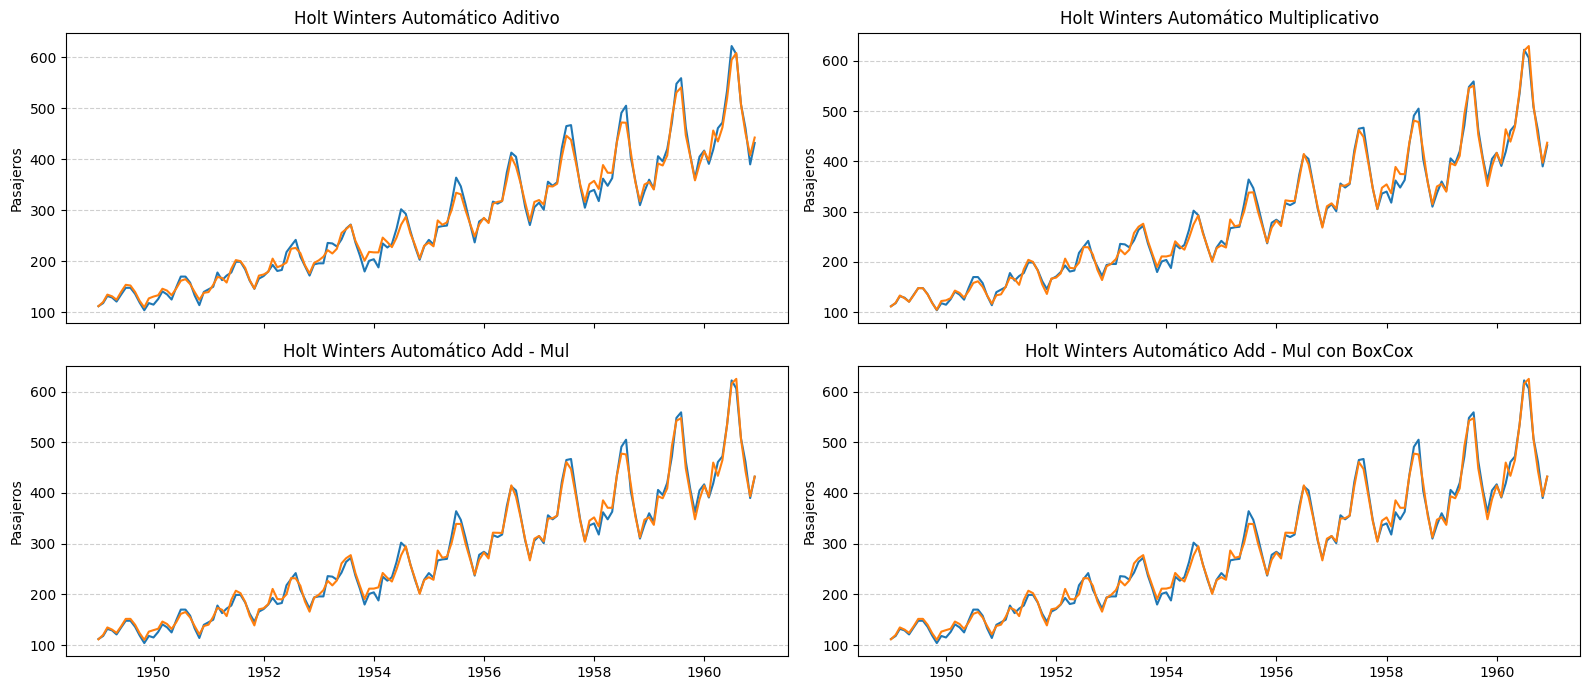

In [24]:
fig, ax = plt.subplots(2,2, figsize=(16, 7), sharex=True)

# Gráfico Auto Aditivo
ax[0,0].plot(df.index, df['Pasajeros'], label='Original')
ax[0,0].plot(df.index, df['hwPasAutoA'], label='Holt Winters Automático Aditivo')
ax[0,0].set_title('Holt Winters Automático Aditivo')
ax[0,0].set_ylabel('Pasajeros')
ax[0,0].grid(axis='y', linestyle='--', alpha=0.6)

# Gráfico Auto Multiplicativo
ax[0,1].plot(df.index, df['Pasajeros'], label='Original')
ax[0,1].plot(df.index, df['hwPasAutoM'], label='Holt Winters Automático Multiplicativo')
ax[0,1].set_title('Holt Winters Automático Multiplicativo')
ax[0,1].set_ylabel('Pasajeros')
ax[0,1].grid(axis='y', linestyle='--', alpha=0.6)

# Gráfico Auto Aditivo + Multiplicativo
ax[1,0].plot(df.index, df['Pasajeros'], label='Original')
ax[1,0].plot(df.index, df['hwPasAutoAM'], label='Holt Winters Automático Add - Mul')
ax[1,0].set_title('Holt Winters Automático Add - Mul')
ax[1,0].set_ylabel('Pasajeros')
ax[1,0].grid(axis='y', linestyle='--', alpha=0.6)

# Gráfico Auto Aditivo + Multiplicativo Box Cox
ax[1,1].plot(df.index, df['Pasajeros'], label='Original')
ax[1,1].plot(df.index, df['hwPasAutoAMBC'], label='Holt Winters Automático Add - Mul con BoxCox')
ax[1,1].set_title('Holt Winters Automático Add - Mul con BoxCox')
ax[1,1].set_ylabel('Pasajeros')
ax[1,1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [25]:
forecast_hwPasAutoAM = hwPasAutoAM.forecast(steps=60)

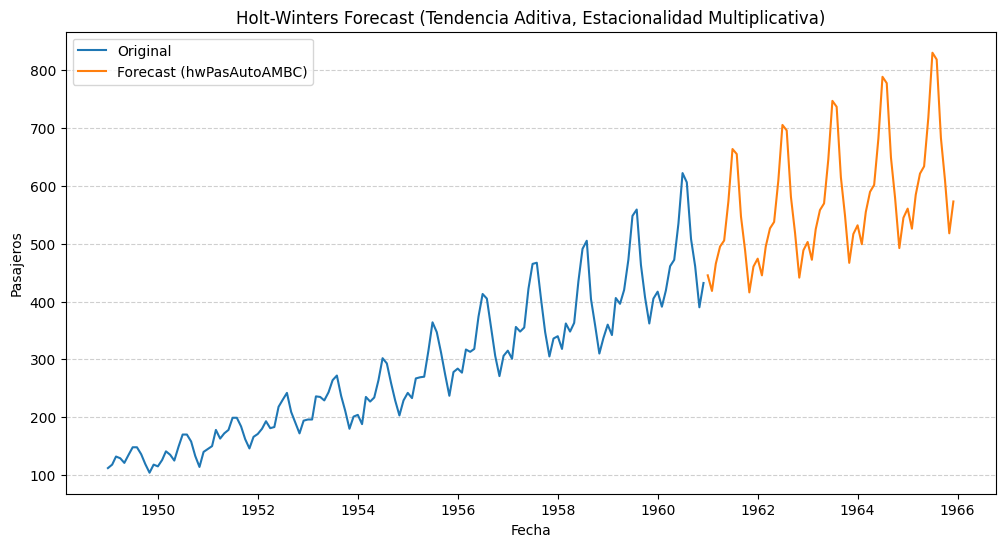

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(df['Pasajeros'], label='Original')
plt.plot(forecast_hwPasAutoAM, label='Forecast (hwPasAutoAMBC)')
plt.title('Holt-Winters Forecast (Tendencia Aditiva, Estacionalidad Multiplicativa)')
plt.xlabel('Fecha')
plt.ylabel('Pasajeros')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()